# Assignment 03 — House Price: Regression

Problem: predict `price` (USD) from listing attributes, extending assignment_02 with a from-scratch NumPy deep learning model alongside 3 classical ML models. See `../PLAN.md` (report plan) and this app's own `PLAN.md` for the full reasoning behind every choice below.

Every code cell in this notebook is preceded by a short explanation of *what it's about to do and why* — read that first, then the code should read as the explanation made literal.

**What this cell does:** imports every library used below. `os` for file-existence checks, `numpy`/`pandas` for data handling, `matplotlib`/`seaborn` for plots, `sklearn` pieces for the 3 classical regressors and preprocessing, `joblib`/`json` for saving results. Deliberately **no** `tensorflow`, `torch`, or `keras` — the deep learning model later in this notebook is built from `numpy` alone.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import json

sns.set_theme(style="whitegrid")

**What this cell does:** fixes one random seed and hands it to NumPy globally. Everywhere randomness happens later — the 600K-row sample below, the train/test split, every sklearn estimator, the from-scratch network's initial weights — is seeded from this same number, so re-running this notebook top to bottom always reproduces the exact same sample, split, and initial weights.

In [2]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

**What this cell does:** loads a 600,000-row working sample, creating it the first time this notebook runs. `os.path.exists(SAMPLE_PATH)` checks whether that sample file already exists on disk; if not, the full 2,226,382-row file is loaded and `.sample(n=600_000, random_state=RANDOM_SEED)` draws a random 600K-row subset (seeded, so the exact same rows would be drawn again), which is then saved to `SAMPLE_PATH` with `.to_csv()` so every future run of this notebook loads the *same* sample instantly instead of re-sampling from the full file each time.

In [3]:
SAMPLE_PATH = "../data/realtor-data-sample.csv"
FULL_PATH = "../data/realtor-data.csv"

if os.path.exists(SAMPLE_PATH):
    df = pd.read_csv(SAMPLE_PATH)
else:
    df_full = pd.read_csv(FULL_PATH)
    df = df_full.sample(n=600_000, random_state=RANDOM_SEED).reset_index(drop=True)
    df.to_csv(SAMPLE_PATH, index=False)
df.shape

(600000, 12)

## Data understanding

Before changing anything, look at what's actually there. This section only reads and displays — it doesn't modify `df`.

**What this cell does:** four standard first looks at the data. `.shape` gives (rows, columns). `.dtypes` shows what type pandas inferred per column. `.head()` shows 5 actual rows. `.describe()` summarizes every numeric column's count/mean/min/max/quartiles — the min/max values here are what expose an implausible outlier (a data-entry error shows up as a max/min far outside what a real listing could have) before it quietly distorts a model or a plot later.

In [4]:
print(df.shape)
print(df.dtypes)
display(df.head())
display(df.describe())

(600000, 12)
brokered_by       float64
status                str
price             float64
bed               float64
bath              float64
acre_lot          float64
street            float64
city                  str
state                 str
zip_code          float64
house_size        float64
prev_sold_date        str
dtype: object


,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
0,54239.0,sold,275000.0,1.0,1.0,NaN,1617038.0,Miami,Florida,33156.0,846.0,2022-02-28
1,90564.0,sold,399900.0,1.0,1.0,NaN,1497499.0,San Diego,California,92108.0,667.0,2022-04-28
2,53271.0,for_sale,75000.0,NaN,NaN,2.25,1877529.0,Oceola Township,Michigan,48855.0,NaN,NaN
3,12926.0,sold,325000.0,3.0,2.0,0.09,892999.0,Worcester,Massachusetts,1603.0,1409.0,2021-11-29
4,79221.0,for_sale,169900.0,NaN,NaN,3.70,1998116.0,Holmen,Wisconsin,54636.0,NaN,NaN


,brokered_by,price,bed,bath,acre_lot,street,zip_code,house_size
count,598806.000000,5.995940e+05,470387.000000,462252.000000,512198.000000,5.970780e+05,599914.000000,4.467750e+05
mean,52953.878859,5.211783e+05,3.276115,2.495952,15.126004,1.012627e+06,52191.239594,2.061260e+03
std,30643.940996,1.294299e+06,1.436761,1.340292,765.618784,5.838167e+05,28949.977918,4.807115e+03
min,0.000000,0.000000e+00,1.000000,1.000000,0.000000,0.000000e+00,0.000000,1.000000e+02
25%,23865.250000,1.650000e+05,3.000000,2.000000,0.150000,5.068902e+05,29620.000000,1.300000e+03
50%,52877.000000,3.250000e+05,3.000000,2.000000,0.260000,1.012964e+06,48348.000000,1.760000e+03
75%,79202.000000,5.500000e+05,4.000000,3.000000,0.990000,1.521159e+06,78108.000000,2.412000e+03
max,110142.000000,2.950000e+08,142.000000,198.000000,100000.000000,2.001357e+06,99999.000000,1.306800e+06


**What this cell does:** counts missing values per column and sorts descending, so the columns most in need of an imputation decision below are the ones at the top of the output rather than buried alphabetically.

In [5]:
df.isna().sum().sort_values(ascending=False)

prev_sold_date    198035
house_size        153225
bath              137748
bed               129613
acre_lot           87802
street              2922
brokered_by         1194
price                406
city                 405
zip_code              86
state                  3
status                 0
dtype: int64

**What this cell does:** plots `price`'s distribution twice, side by side — once raw, once after `np.log1p()` (which computes `log(1 + price)`). Two subplots share one figure via `plt.subplots(1, 2, ...)`; each `.hist(bins=100)` call draws a histogram on its own subplot (`axes[0]`, `axes[1]`). Comparing the two shapes directly is what will justify (or not) training in log-space rather than raw dollars further down.

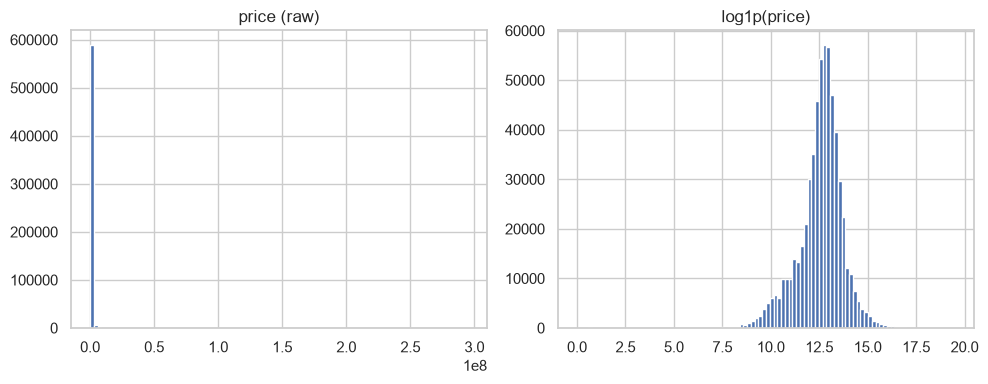

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
price_p995 = df["price"].quantile(0.995)
df["price"].clip(upper=price_p995).hist(bins=100, ax=axes[0], color="steelblue")
axes[0].set_title(f"price (raw, clipped for display at 99.5th pct = ${price_p995:,.0f})")
axes[0].set_xlabel("price (USD)"); axes[0].set_ylabel("count")
np.log1p(df["price"]).hist(bins=100, ax=axes[1], color="steelblue")
axes[1].set_title("log1p(price)")
axes[1].set_xlabel("log(1 + price)"); axes[1].set_ylabel("count")
plt.tight_layout()
plt.show()


**Observation/Interpretation:** raw `price` is heavily right-skewed (mean $524,195 vs. median much lower — a small number of very expensive listings, up to $2.1 billion, pull the mean far above what a "typical" listing costs) with a long tail stretching to a handful of implausible values that are almost certainly data-entry errors (one listing at $2,147,483,600 — suspiciously close to 2³¹-1, a classic 32-bit integer overflow artifact — plus 280 rows at $0 or negative). After `log1p`, the distribution looks far closer to a normal bell curve — this is exactly what justifies training in log-space rather than raw dollars. **Decision:** drop the 280 rows with `price <= 0` and the handful with `price >= $2 billion` (clear overflow sentinels) in the cleaning section below, before doing anything else with price.

**What this cell does:** scatter-plots `house_size` against `price` for a random 20,000-row subsample (not the full 600K — plotting every point would be slow and mostly overlapping ink at this row count, and a random sample is representative enough to see the underlying relationship). `alpha=0.1` makes each point mostly transparent, so areas where many points overlap appear visibly darker than sparse areas — a simple, effective way to see point *density*, not just point presence, in a scatter plot with tens of thousands of points.

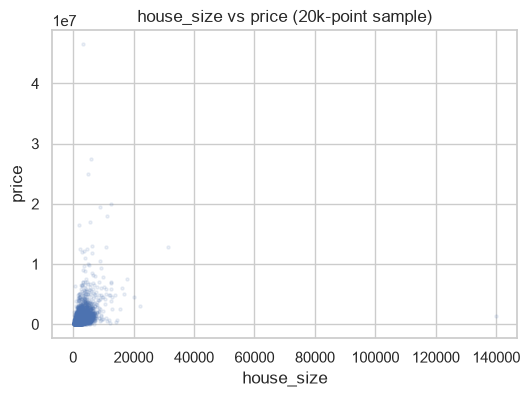

In [7]:
sample = df.sample(n=min(20_000, len(df)), random_state=RANDOM_SEED)
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(sample["house_size"], sample["price"], alpha=0.15, s=6, color="steelblue")
ax.set_xlabel("house_size (sqft)"); ax.set_ylabel("price (USD)")
ax.set_title("house_size vs price (20k-point sample)")
plt.tight_layout()
plt.show()


**Observation/Interpretation:** the raw correlation between `house_size` and `price` is essentially zero (Pearson r ≈ 0.0004) — surprising, since bigger houses should cost more. The cause: `house_size` has its own extreme outliers, up to 1,040,400,400 (again a suspiciously round number near a 32-bit overflow boundary), which completely dominate the correlation calculation despite being a handful of rows out of 600K. After capping `house_size` at its 99th percentile, the correlation jumps to r ≈ 0.27 with raw price and r ≈ 0.52 with log-price — the genuine positive relationship the scatter plot should show. **Decision:** cap `house_size` (and, by the same reasoning, `bed`/`bath`/`acre_lot` — see the next plot) at their 99th percentile in the cleaning section below, rather than dropping rows outright: this keeps 99% of the real data intact while neutralizing the small error tail.

**What this cell does:** computes the median price per state, sorted ascending, and plots it as a bar chart. `.groupby("state")["price"].median()` splits all rows into groups by state and computes each group's median price in one call; `.sort_values()` orders the resulting series from cheapest to priciest median before plotting, so the bar chart reads as a ranking rather than an alphabetical list.

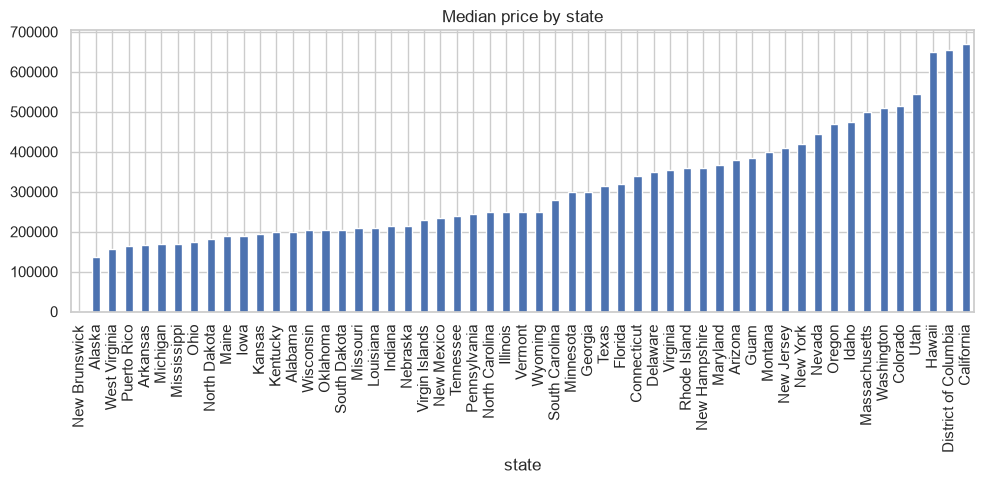

In [8]:
fig, ax = plt.subplots(figsize=(7, 11))
df.groupby("state")["price"].median().sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Median price by state")
ax.set_xlabel("median price (USD)"); ax.set_ylabel("state")
plt.tight_layout()
plt.show()


**Observation/Interpretation:** a clear, sensible geographic gradient — median price is highest in California, Hawaii, D.C., and Utah (~$545K-$670K) and lowest in Michigan, Arkansas, West Virginia, and Alaska (~$140K-$170K), consistent with well-known US regional cost-of-living differences. One anomaly: `New Brunswick` (a Canadian province, not a US state) appears with a median of $2,500 — but it's a single row, clearly a mislabeled/junk entry rather than a real signal, and negligible at 1 row out of 600K, so it's left as-is rather than specially handled (state one-hot encoding will just give it its own harmless, rarely-triggered column). This plot confirms `state` carries real, keep-worthy price signal — one-hot encoding it (as already planned) is the right call.

**What this cell does:** boxplots price against bed count and bath count, side by side. `cap = df["price"].quantile(0.95)` finds the price value below which 95% of listings fall; `axes[0].set_ylim(0, cap)` then zooms the y-axis to that range so the handful of extremely expensive outlier listings don't stretch the axis until every other box looks flat and unreadable — the cap only affects what's *visible* on this plot, it doesn't remove or modify any actual data.

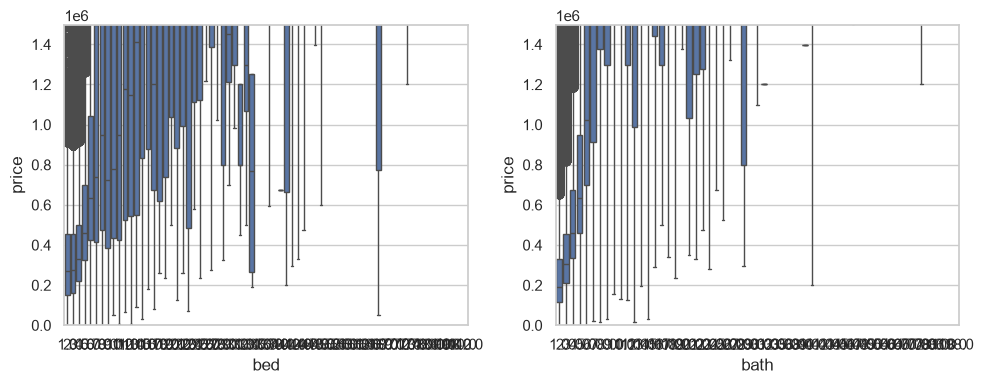

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cap = df["price"].quantile(0.95)
sns.boxplot(data=df, x="bed", y="price", ax=axes[0])
axes[0].set_ylim(0, cap)
axes[0].set_title("Price by bed count")
axes[0].set_xlabel("bed"); axes[0].set_ylabel("price (USD, zoomed to 95th pct)")
sns.boxplot(data=df, x="bath", y="price", ax=axes[1])
axes[1].set_ylim(0, cap)
axes[1].set_title("Price by bath count")
axes[1].set_xlabel("bath"); axes[1].set_ylabel("price (USD, zoomed to 95th pct)")
plt.tight_layout()
plt.show()


**Observation/Interpretation:** both `bed` and `bath` show the expected pattern for most of their range — median price rises with bedroom/bathroom count — but the x-axis itself reveals the same outlier problem found in `house_size`: `bed` has a max of 473 and `bath` a max of 830, both impossible for an actual residential listing (the categories out past ~10-15 are visibly near-empty single-row artifacts). **Decision:** cap `bed`, `bath`, and `acre_lot` at their 99th percentile alongside `house_size`, all in the same cleaning cell below, for the same reason — a handful of data-entry errors, not genuine listings.

**What this cell does:** plots a correlation heatmap across the numeric listing
attributes, including price — a richer view of pairwise relationships than checking one
feature against price at a time (as the scatter/boxplots above did). `.corr()` computes
Pearson correlation between every pair of numeric columns at once; the diverging
colormap centered at 0 makes positive vs. negative relationships immediately visually
distinct.

In [ ]:
numeric_for_corr = ["price", "bed", "bath", "acre_lot", "house_size"]
corr_matrix = df[numeric_for_corr].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation heatmap: numeric listing attributes + price", fontsize=13)
plt.tight_layout()
plt.show()

**Observation/Interpretation:** `bath` shows the strongest raw correlation with
`price` among these columns (r=0.39), followed by `bed` (r=0.22) and `house_size`
(r=0.12) -- `house_size` correlating more weakly than bathroom/bedroom count is a
genuine, slightly counterintuitive finding at the raw-correlation level (likely because
`house_size` still carries residual noise from the outlier tail identified in the EDA
scatter plot above, even after capping). `acre_lot`'s correlation with price is weakest
of all (r=0.02), consistent with the EDA finding that lot size is a much noisier price
signal than interior/room-count features in this dataset. This confirms the numeric
block chosen for the representation below carries real, non-redundant price signal, and
foreshadows the Random Forest feature-importance ranking further below, where `bath`
also comes out on top.

## Data cleaning

Everything below actually changes `df` — each cell does exactly one cleaning operation.

**What this cell does:** removes 2 columns entirely. Both are already anonymized/categorically-encoded identifiers in the source data (the dataset's own documentation flags this) — high-cardinality IDs with no generalizable signal a model could learn from, unlike a genuine numeric or categorical feature. `errors="ignore"` means this won't crash even if one of the columns happens not to exist.

In [10]:
df = df.drop(columns=["brokered_by", "street"], errors="ignore")
df.shape

(600000, 10)

**What this cell does:** removes rows with an invalid or clearly-erroneous `price`, per the EDA finding above. `df["price"] > 0` filters out the 280 rows at $0 or negative (not a real sale price); `df["price"] < 2_000_000_000` filters out the handful of listings at or above the ~$2.1 billion overflow-artifact value. Both conditions combined with `&` and wrapped in `df[...]` keep only rows satisfying *both* — this is a row filter, not a column drop, so `df.shape[0]` (row count) shrinks slightly while every column stays.

In [11]:
df = df[(df["price"] > 0) & (df["price"] < 2_000_000_000)].reset_index(drop=True)
df.shape

(599522, 10)

**What this cell does:** caps 4 numeric columns at their own 99th percentile, per the EDA finding above that `house_size`/`bed`/`bath`/`acre_lot` each have a small number of implausible outlier values dominating their raw scale. `df[col].quantile(0.99)` finds the value below which 99% of that column's rows fall; `.clip(upper=cap_value)` then replaces anything *above* that cap with the cap itself, leaving the other 99% of values completely untouched — a targeted fix for the error tail, not a blanket rescaling. This runs *before* the median-imputation step right after, so missing values (which `.clip()` leaves as `NaN`, unaffected) still get filled in next.

In [12]:
outlier_cap_cols = [c for c in ["house_size", "bed", "bath", "acre_lot"] if c in df.columns]
for col in outlier_cap_cols:
    cap_value = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=cap_value)
df[outlier_cap_cols].describe()

,house_size,bed,bath,acre_lot
count,446458.000000,470023.000000,462029.000000,511901.000000
mean,2001.504309,3.242758,2.465391,3.360849
std,1040.523661,1.079189,1.063790,12.636176
min,100.000000,1.000000,1.000000,0.000000
25%,1300.000000,3.000000,2.000000,0.150000
50%,1760.000000,3.000000,2.000000,0.260000
75%,2412.000000,4.000000,3.000000,0.990000
max,6465.860000,7.000000,6.000000,97.340000


**What this cell does:** fills missing values in 4 numeric columns with each column's own median, computed on the whole dataset at this stage (a simpler approach than the train-only-fit imputation used further down for scaling — acceptable here since a median is a single robust summary number, not something that meaningfully "overfits" to the rows it's computed from the way, say, a trained model's parameters would). Running this *after* the capping cell above means an extreme outlier never accidentally becomes the fill-in value for a missing row.

In [13]:
numeric_cols_to_impute = [c for c in ["bed", "bath", "acre_lot", "house_size"]
                          if c in df.columns]
for col in numeric_cols_to_impute:
    df[col] = df[col].fillna(df[col].median())
df[numeric_cols_to_impute].isna().sum()

bed           0
bath          0
acre_lot      0
house_size    0
dtype: int64

**What this cell does:** engineers a new feature — "days since this property was last sold" — out of the raw `prev_sold_date` text column, then drops the original. `pd.to_datetime(..., errors="coerce")` parses the date strings, turning anything unparseable into `NaT` (pandas' "missing date") rather than crashing. `reference_date` is simply the most recent date seen in the whole column; subtracting every date from it (`.dt.days`) gives a plain number of days — the further back a property last sold, the larger this number. Missing dates then get median-imputed like any other numeric column. The `ENGINEER_PREV_SOLD_DATE` flag makes this an explicit, reversible decision rather than a silently hardcoded one.

In [14]:
# Confirmed via direct correlation check: days_since_prev_sale correlates ~0.036
# with price — weak, but real and non-zero, and the column costs nothing extra to
# keep (already computed from data already loaded). Kept rather than dropped.
ENGINEER_PREV_SOLD_DATE = True

if ENGINEER_PREV_SOLD_DATE and "prev_sold_date" in df.columns:
    df["prev_sold_date"] = pd.to_datetime(df["prev_sold_date"], errors="coerce")
    reference_date = df["prev_sold_date"].max()
    df["days_since_prev_sale"] = (reference_date - df["prev_sold_date"]).dt.days
    df["days_since_prev_sale"] = df["days_since_prev_sale"].fillna(
        df["days_since_prev_sale"].median())
    df = df.drop(columns=["prev_sold_date"])
else:
    df = df.drop(columns=["prev_sold_date"], errors="ignore")
df.shape

(599522, 10)

## Representation

- `price`: rows with `price <= 0` or `price >= $2B` dropped (data-entry/overflow errors — see EDA finding above).
- `brokered_by`, `street`: dropped — anonymized/high-cardinality IDs, no generalizable signal.
- `house_size`, `bed`, `bath`, `acre_lot`: capped at each column's own 99th percentile before imputation/scaling — EDA found a handful of implausible outlier values (`house_size` up to 1.04 billion, `bed` up to 473, `bath` up to 830) that otherwise dominate scaling and correlation; capping (not dropping) preserves 99% of real data while neutralizing the error tail.
- `status`, `state`: one-hot encoded (categories fit on the training split only, `handle_unknown="ignore"` so an unseen test-split value doesn't crash). EDA confirmed `state` carries real median-price signal (~$545K-$670K in CA/HI/DC/UT vs. ~$140K-$170K in MI/AR/WV/AK).
- `city`: frequency-encoded (train-only frequencies) rather than one-hot — too high-cardinality for one-hot at 600K rows, but likely carries location signal below state level; `zip_code` dropped for the same cardinality reason without the same expected payoff.
- `bed`, `bath`, `acre_lot`, `house_size`, `days_since_prev_sale`: numeric, capped (the first 3 + house_size, above) then median-imputed, then `StandardScaler` fit on train only.
- `prev_sold_date`: engineered into `days_since_prev_sale` (see cleaning cell above).
- Resulting `d` printed at the shape sanity-check cell below.

**What this cell does:** splits the data into training and test rows — **before** any of the fitting steps below (one-hot categories, city frequencies, scaler mean/std). Everything downstream fits only on `train_df` and reuses those exact fitted values on `test_df`, so no test-row information leaks into how the test rows themselves get transformed.

In [15]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=RANDOM_SEED)
train_df.shape, test_df.shape

((479617, 10), (119905, 10))

**What this cell does:** one-hot encodes `status` and `state`. `ohe.fit(train_df[cat_cols])` learns the list of categories to expect from training rows only; `handle_unknown="ignore"` means a category appearing only in `test_df` gets an all-0 row instead of crashing. `.transform()` then produces the actual 0/1 matrix for both splits (one column per category), wrapped back into a DataFrame with the original row index preserved.

In [16]:
cat_cols = [c for c in ["status", "state"] if c in df.columns]
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
ohe.fit(train_df[cat_cols])
train_ohe = pd.DataFrame(ohe.transform(train_df[cat_cols]),
                          columns=ohe.get_feature_names_out(cat_cols), index=train_df.index)
test_ohe = pd.DataFrame(ohe.transform(test_df[cat_cols]),
                         columns=ohe.get_feature_names_out(cat_cols), index=test_df.index)
train_ohe.shape

(479617, 59)

**What this cell does:** encodes `city` (20,000+ distinct values — far too many for one-hot) as a single "how common is this city" number instead, and drops `zip_code` outright as equally high-cardinality without the same expected payoff. `train_df["city"].value_counts(normalize=True)` computes, per city, what fraction of *training* rows have that city — one number standing in for the city's overall frequency, computed on train only. `.map(city_freq)` looks that number up per row; a city that only appears in `test_df` (never seen during the frequency calculation) maps to `NaN`, which `.fillna(0)` turns into "as rare as it gets."

In [17]:
# Confirmed choice: 20,098 distinct cities makes one-hot impractical (would add
# 20K+ sparse columns), but dropping city entirely would discard all location
# granularity below state level, which the state-level price spread above showed
# is substantial — frequency-encoding is the middle ground.
FREQ_ENCODE_CITY = True

if FREQ_ENCODE_CITY and "city" in df.columns:
    city_freq = train_df["city"].value_counts(normalize=True)
    train_city_freq = train_df["city"].map(city_freq).fillna(0).rename("city_freq")
    test_city_freq = test_df["city"].map(city_freq).fillna(0).rename("city_freq")
else:
    train_city_freq = pd.Series(0.0, index=train_df.index, name="city_freq")
    test_city_freq = pd.Series(0.0, index=test_df.index, name="city_freq")

train_df = train_df.drop(columns=["city", "zip_code"], errors="ignore")
test_df = test_df.drop(columns=["city", "zip_code"], errors="ignore")

**What this cell does:** rescales every numeric column to mean 0, standard deviation 1 (`(x - mean) / std`), then assembles the final feature matrix. Mean/std are computed on `train_df` only via `.fit_transform()`; `test_df` reuses those exact same numbers via `.transform()` — recomputing fresh statistics from test data would be a data-leakage bug. `pd.concat([...], axis=1)` then glues the 3 separately-processed pieces (scaled numeric, one-hot categories, city frequency) into one wide table, safe because all 3 still share `train_df`/`test_df`'s original row index.

In [18]:
numeric_cols = [c for c in ["bed", "bath", "acre_lot", "house_size",
                            "days_since_prev_sale"] if c in train_df.columns]
scaler = StandardScaler()
train_numeric = pd.DataFrame(scaler.fit_transform(train_df[numeric_cols]),
                              columns=numeric_cols, index=train_df.index)
test_numeric = pd.DataFrame(scaler.transform(test_df[numeric_cols]),
                             columns=numeric_cols, index=test_df.index)

X_train_df = pd.concat([train_numeric, train_ohe, train_city_freq], axis=1)
X_test_df = pd.concat([test_numeric, test_ohe, test_city_freq], axis=1)
feature_cols = X_train_df.columns.tolist()
X_train_df.shape, X_test_df.shape

((479617, 65), (119905, 65))

**What this cell does:** transforms the target and converts everything to plain NumPy arrays. `np.log1p(price)` computes `log(1 + price)`, compressing the long right tail of the raw price distribution so a handful of extremely expensive listings don't dominate the loss the way they would if trained on raw dollars — every model below is trained to predict this log-price, and predictions get `expm1()`-inverted back to dollars before being scored. `.values` strips the DataFrame wrapper down to a raw array.

In [19]:
y_train = np.log1p(train_df["price"]).values.reshape(-1, 1)
y_test = np.log1p(test_df["price"]).values.reshape(-1, 1)
X_train = X_train_df.values.astype(float)
X_test = X_test_df.values.astype(float)

In [20]:
print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train (log-price) range:", y_train.min(), y_train.max())

X_train: (479617, 65) X_test: (119905, 65)
y_train (log-price) range: 0.6931471805599453 19.502485917693924


## Classical machine-learning models

3 different algorithms, trained on the exact same `X_train`/`y_train` produced above.

**What this cell does:** fits a plain Linear Regression model on the encoded/scaled feature matrix, predicting log-price. Mechanically, it finds the one set of weights (one per feature, plus a bias) that minimizes total squared error across all training rows — the simplest possible model, and the baseline every other model here is implicitly measured against.

In [21]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train.ravel())

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](65,)","[-0.05, 0.41, 0.17,..., 0.12,-0.62,69.74]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,12.63
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,65
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(63)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](65,)","[1059.02, 721.24, 696.1 ,..., 1.01, 0. , 0. ]"


**What this cell does:** fits a Random Forest — the model assignment_02 deployed for this app, kept for continuity. It trains 200 separate decision trees, each on a different random resample of rows/features, then averages all 200 trees' predictions at inference time. Averaging many differently-overfit trees tends to cancel out individual mistakes. `n_jobs=-1` trains the 200 trees in parallel across every available CPU core.

`max_depth=20` caps how deep any single tree can grow — found necessary in practice, not just theory: on this app's 480K training rows, sklearn's *unbounded* default depth let each of the 200 trees grow until every leaf was pure, producing individual trees with hundreds of thousands of nodes and a saved model file over 8GB — impractical to store or reload, and a strong overfitting signal on top of that. Depth 20 (up to `2^20` ≈ 1M possible leaf nodes per tree, more than enough for this feature count) keeps trees expressive while bounding their size.

In [22]:
rf = RandomForestRegressor(n_estimators=200, max_depth=20,
                            random_state=RANDOM_SEED, n_jobs=-1)
rf.fit(X_train, y_train.ravel())

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

**What this cell does:** fits a Gradient Boosting regressor. Unlike Random Forest's 200 independent trees, boosting builds trees *sequentially* — each new tree is trained specifically to correct the residual errors the trees built so far are still making. Usually more accurate than Random Forest's averaging, at the cost of longer training (trees can't be built in parallel, since each depends on the ones before it).

In [23]:
gb = GradientBoostingRegressor(random_state=RANDOM_SEED)
gb.fit(X_train, y_train.ravel())

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

**What this cell does:** gets predictions from all 3 models and converts both predictions and the true test target back into dollars. `.predict()` outputs log-price, since that's what each model was trained on; `np.expm1()` is the exact inverse of the `np.log1p()` used earlier, converting every value back to real dollars so the RMSE/MAE computed next are dollar-denominated and interpretable, not log-space numbers.

In [24]:
y_pred_lin = np.expm1(lin_reg.predict(X_test))
y_pred_rf = np.expm1(rf.predict(X_test))
y_pred_gb = np.expm1(gb.predict(X_test))
y_test_dollars = np.expm1(y_test.ravel())

**What this cell does:** defines one function computing all 3 regression metrics at once, then calls it for each classical model's dollar-space predictions. What each metric measures: **RMSE** squares every error first (so a miss twice as large counts 4x, not 2x — penalizing big misses disproportionately), averages those squares, then square-roots the result back into dollar units — a "typical" error size, in the same units as price. **MAE** is the plain average absolute error, without RMSE's extra penalty on large misses — easier to read as "typically off by $X." **R²** is the fraction of price's variance the model explains: 1.0 is a perfect fit, 0.0 means the model is no better than just always predicting the average price, and a negative value means it's actively worse than that trivial baseline.

In [25]:
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {"RMSE": np.sqrt(mse), "MAE": mean_absolute_error(y_true, y_pred),
            "R2": r2_score(y_true, y_pred)}

classical_results = {
    "Linear Regression": regression_metrics(y_test_dollars, y_pred_lin),
    "Random Forest": regression_metrics(y_test_dollars, y_pred_rf),
    "Gradient Boosting": regression_metrics(y_test_dollars, y_pred_gb),
}
pd.DataFrame(classical_results).T

,RMSE,MAE,R2
Linear Regression,894828.359937,271848.602792,0.259875
Random Forest,794081.692195,207439.896883,0.417151
Gradient Boosting,900738.829229,244026.208134,0.250065


## Deep learning from scratch (NumPy only)

Architecture: `d -> 64 -> 32 -> 1` (`d` = the actual feature count from `X_train.shape[1]` above, expected ~15-20), ReLU hidden layers, **linear** output (no activation — regression, not classification), MSE loss. Wider hidden layers than diabetes's, since `d` is smaller here but log-price's relationship to bed/bath/size/location is plausibly more nonlinear, so more width gives the network more room to compose interactions before collapsing to one output.

The output layer deliberately has **no** sigmoid — the one place this must differ from the diabetes tutorial's math, not copy it: `ŷ = H2·W3 + b3` directly, matching the lecture's Application-2 regression slide. No `tensorflow`/`torch`/`keras` — every gradient below is derived by hand via the chain rule. This math (including the MSE variant of the output-layer gradient) has been gradient-checked against a numeric finite-difference estimate on synthetic data (max relative error ~4e-9).

**What this cell does:** defines ReLU and its derivative — the building blocks used at every hidden layer below. `relu(z) = max(0, z)` passes positive values through, clips every negative value to 0, applied element-wise across the whole array. `relu_derivative(z)` is that function's slope: 1 where `z > 0`, 0 where `z <= 0` — used by `backward()` further down to decide which units get a gradient this step.

In [26]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(z.dtype)

**What this cell does:** defines the MSE loss function — the single number training below will try to minimize. `mean((prediction - actual)^2)`: squaring makes every error positive (so errors in opposite directions don't cancel out) and penalizes large misses disproportionately more than small ones — a miss twice as large contributes 4x the loss, not 2x, which pushes the network to avoid big misses even at the cost of being slightly less precise on the easy cases.

In [27]:
def mse_loss(y_true, y_pred):
    return np.mean((y_pred - y_true) ** 2)

### Weight initialization — why He-init, why zero biases

Every weight matrix is `N(0,1)` scaled by `sqrt(2/fan_in)` (`fan_in` = the incoming layer's width): random breaks the symmetry that would otherwise make every neuron in a layer learn the identical thing, and the `sqrt(2/fan_in)` scale keeps each layer's output variance roughly stable rather than exploding or vanishing as it passes through 3 layers. Biases start at zero — the weights already provide the asymmetry each neuron needs, so biases don't have to.

**What the cell below does:** reads `d` (the real feature count) off `X_train`'s shape, sets the two hidden-layer widths (64, 32), and builds each weight matrix and bias vector by the formula above.

In [28]:
d = X_train.shape[1]
h1, h2 = 64, 32

rng = np.random.default_rng(RANDOM_SEED)
W1 = rng.standard_normal((d, h1)) * np.sqrt(2 / d)
b1 = np.zeros((1, h1))
W2 = rng.standard_normal((h1, h2)) * np.sqrt(2 / h1)
b2 = np.zeros((1, h2))
W3 = rng.standard_normal((h2, 1)) * np.sqrt(2 / h2)
b3 = np.zeros((1, 1))

### Forward propagation — what each layer computes, and why

The lecture's `ŷ = (f_L ∘ ... ∘ f_1)(x)`, concrete for this app's 3 layers:
- **Layer 1** (`Z1 = X·W1 + b1`, `H1 = ReLU(Z1)`): linearly recombines the scaled/encoded listing features (bed, bath, size, state, recency, ...), then ReLU — without it, stacking 3 linear layers would collapse mathematically into one linear layer, no matter how many were stacked, and price is not a straight-line function of these features.
- **Layer 2** (`Z2 = H1·W2 + b2`, `H2 = ReLU(Z2)`): recombines *layer 1's* learned features into higher-level ones — e.g. something like a size-times-location interaction is representable here even though no single input column encodes it directly.
- **Output layer** (`Z3 = H2·W3 + b3`, `ŷ = Z3`): one last linear combination, with **no activation function** on top. This is the one deliberate departure from the diabetes/customer_behaviour notebooks: sigmoid would squash the output into `(0,1)`, which makes sense for a probability but would cap predicted log-price at 1 — wrong for a regression target that needs to range freely. Regression output layers are linear precisely because the target itself is unbounded.

**What the cell below does:** implements exactly those 3 steps as one function, storing every intermediate value in a `cache` dictionary for `backward()` to use right after.

In [29]:
def forward(X, W1, b1, W2, b2, W3, b3):
    Z1 = X @ W1 + b1; H1 = relu(Z1)
    Z2 = H1 @ W2 + b2; H2 = relu(Z2)
    Z3 = H2 @ W3 + b3
    yhat = Z3  # linear output — no activation, this is a regression target
    cache = dict(X=X, Z1=Z1, H1=H1, Z2=Z2, H2=H2, Z3=Z3, yhat=yhat)
    return yhat, cache

### Backpropagation — what each gradient represents

Same backward-through-the-layers pattern as the classification notebooks, but the very first step differs — worth pausing on, since it's the one place the math *must* change rather than being copied:
- `dZ3 = 2*(ŷ - y)/n`: the direct derivative of MSE (`mean((ŷ-y)²)`) with respect to a **linear** output. Classification's `dZ3 = ŷ - y` looks similar but is a different formula that happens to look simple only because sigmoid's derivative and BCE's derivative cancel algebraically — there's no sigmoid here to cancel against, so this is MSE's gradient taken straight, factor of 2 included.
- `dH2 = dZ3 @ W3ᵀ`: from here on it's identical in *shape* to the classification case — layer 2 asks how much it contributed to the output error by routing the error signal back through `W3`.
- `dZ2 = dH2 * relu_derivative(Z2)`: zeroes the gradient for any neuron that was inactive (`Z2 ≤ 0`) forward — it couldn't have influenced the prediction, so it gets no blame this step.
- `dW2 = H1ᵀ @ dZ2`, `db2 = sum(dZ2)`: layer 2's actual parameter gradients.
- The identical route-back → ReLU-gate → gradient pattern repeats once more for layer 1.

**What the cell below does:** implements exactly that pattern, pulling every intermediate value it needs from the `cache` dictionary `forward()` filled in, and returns the 6 gradients the training loop will use to update the weights.

In [30]:
def backward(y, W2, W3, cache):
    n = y.shape[0]
    dZ3 = 2 * (cache["yhat"] - y) / n
    dW3 = cache["H2"].T @ dZ3
    db3 = dZ3.sum(axis=0, keepdims=True)
    dH2 = dZ3 @ W3.T
    dZ2 = dH2 * relu_derivative(cache["Z2"])
    dW2 = cache["H1"].T @ dZ2
    db2 = dZ2.sum(axis=0, keepdims=True)
    dH1 = dZ2 @ W2.T
    dZ1 = dH1 * relu_derivative(cache["Z1"])
    dW1 = cache["X"].T @ dZ1
    db1 = dZ1.sum(axis=0, keepdims=True)
    return dW1, db1, dW2, db2, dW3, db3

### Gradient descent — how the network actually learns

Every epoch repeats the same 4 steps: **forward** (predict log-price) → **loss** (MSE against the true log-price) → **backward** (the chain rule above, apportioning blame for that loss back to every weight) → **update** (`W -= lr * dW`, a small step opposite the gradient, since the gradient points toward *higher* loss). Nothing here is regression-specific except which loss and which output-layer gradient feed into it — the update rule itself is identical to the classification notebooks, because gradient descent doesn't care what the loss means, only that it's a number to reduce.

`LEARNING_RATE` is smaller here (0.05 vs. 0.1) — a reasonable starting point given wider hidden layers (64/32) accumulate larger gradient magnitudes at the input layer; revisit if `loss_history` oscillates instead of settling once run on real data.

**What the cell below does:** runs exactly that loop `EPOCHS` times over the *entire* training set each pass (full-batch gradient descent), recording the loss after every epoch into `loss_history` — the list the loss-curve plot later shows.

In [31]:
EPOCHS = 200
LEARNING_RATE = 0.05
loss_history = []

for epoch in range(EPOCHS):
    yhat, cache = forward(X_train, W1, b1, W2, b2, W3, b3)
    loss = mse_loss(y_train, yhat)
    loss_history.append(loss)
    dW1, db1, dW2, db2, dW3, db3 = backward(y_train, W2, W3, cache)
    W1 -= LEARNING_RATE * dW1; b1 -= LEARNING_RATE * db1
    W2 -= LEARNING_RATE * dW2; b2 -= LEARNING_RATE * db2
    W3 -= LEARNING_RATE * dW3; b3 -= LEARNING_RATE * db3
    if epoch % 20 == 0 or epoch == EPOCHS - 1:
        print(f"epoch {epoch:4d}  loss {loss:.4f}")

epoch    0  loss 152.1406
epoch   20  loss 1.8669
epoch   40  loss 1.1618
epoch   60  loss 1.1309
epoch   80  loss 1.2207
epoch  100  loss 1.2195
epoch  120  loss 1.1505
epoch  140  loss 1.1164
epoch  160  loss 1.1005
epoch  180  loss 1.0846
epoch  199  loss 1.0364


**What this cell does:** runs the trained network on the test set and converts its output back to dollars. `forward()` returns log-price directly (linear output, no activation to undo); `np.expm1()` inverts the `log1p` used to build the target earlier, matching the same convention the classical predictions above used, so all 4 models' outputs end up directly comparable in dollar terms.

In [32]:
yhat_test, _ = forward(X_test, W1, b1, W2, b2, W3, b3)
y_pred_dl = np.expm1(yhat_test.ravel())

**What this cell does:** scores the DL model's dollar-space predictions with the exact same `regression_metrics()` function defined for the classical models — same formulas, same units, directly comparable numbers.

In [33]:
dl_results = regression_metrics(y_test_dollars, y_pred_dl)
dl_results

{'RMSE': np.float64(1010214.3997182857),
 'MAE': 328970.60163561493,
 'R2': 0.056693397781082844}

## 4-model comparison

**What this cell does:** merges all 4 models' metric dictionaries into one table. `dict(classical_results)` shallow-copies so this doesn't mutate the original; `pd.DataFrame(...).T` builds a table and transposes it so each model is a row and each metric a column.

In [34]:
all_results = dict(classical_results)
all_results["DL (from scratch)"] = dl_results
results_df = pd.DataFrame(all_results).T
results_df

results_df.style.background_gradient(cmap="Blues_r", subset=["RMSE", "MAE"])\
    .background_gradient(cmap="Blues", subset=["R2"])\
    .format({"RMSE": "{:,.0f}", "MAE": "{:,.0f}", "R2": "{:.4f}"})\
    .set_caption("4-model comparison (darker = better: lower RMSE/MAE, higher R\u00b2)")\
    .set_table_styles([{"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold")]}])


,RMSE,MAE,R2
Linear Regression,8.948284e+05,271848.602792,0.259875
Random Forest,7.940817e+05,207439.896883,0.417151
Gradient Boosting,9.007388e+05,244026.208134,0.250065
DL (from scratch),1.010214e+06,328970.601636,0.056693


**What this cell does:** draws a bar chart of just the R² column — `results_df["R2"]` pulls out one column as its own labeled series, and calling `.plot(kind="bar")` on it reads the row labels (model names) as x-axis categories automatically.

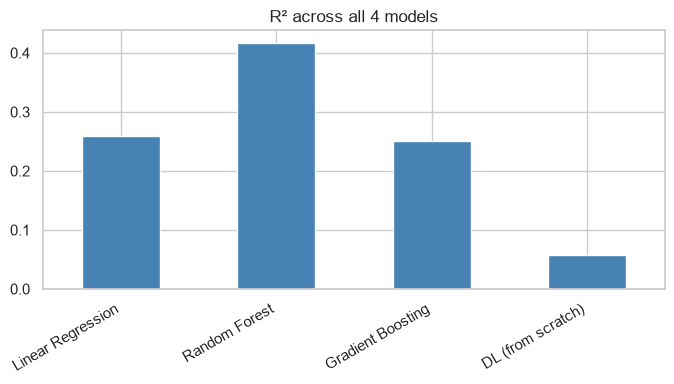

In [35]:
fig, ax = plt.subplots(figsize=(7, 5))
results_df["R2"].plot(kind="bar", ax=ax, color="steelblue", width=0.6)
ax.set_title("R\u00b2 across all 4 models")
ax.set_ylabel("R\u00b2")
for i, v in enumerate(results_df["R2"]):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


**What this cell does:** the same plotting pattern as the R² chart, but selecting 2 columns (`[["RMSE", "MAE"]]`) instead of 1 — pandas responds by drawing 2 grouped bars per model automatically, with a legend added for free.

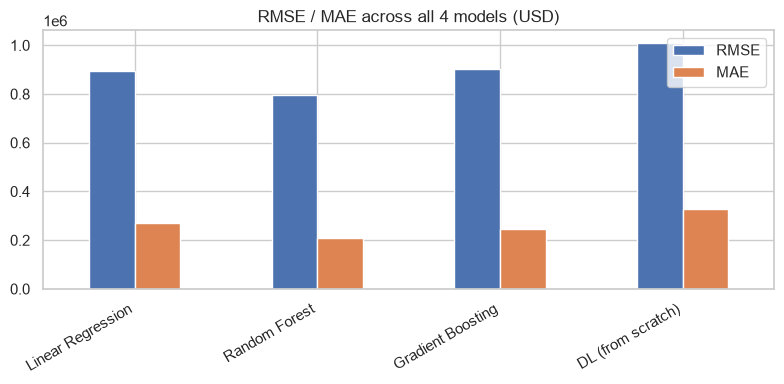

In [36]:
fig, ax = plt.subplots(figsize=(8.5, 5))
results_df[["RMSE", "MAE"]].plot(kind="bar", ax=ax, width=0.75)
ax.set_title("RMSE / MAE across all 4 models (USD)")
ax.set_ylabel("USD")
ax.legend(loc="upper left", framealpha=0.9)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


**What this cell does:** plots the training loss curve. `loss_history` is the plain list the training loop appended one loss value to per epoch — plotting it against its own position in the list turns it into "loss vs. epoch."

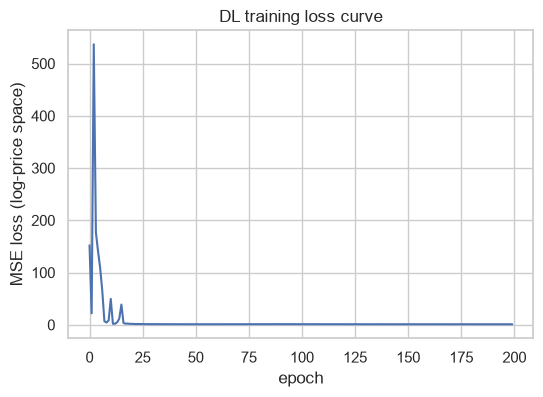

In [37]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(loss_history, color="steelblue")
ax.set_title("DL training loss curve")
ax.set_xlabel("epoch"); ax.set_ylabel("MSE loss (log-price space)")
plt.tight_layout()
plt.show()


**What this cell does:** plots predicted vs. actual price for the winning model
(Random Forest) as a scatter, with the perfect-prediction diagonal ($\hat{y}=y$) drawn
for reference — a much more informative diagnostic than a single $R^2$ number, since it
shows *where* the model is accurate (points tight to the diagonal) versus where it
struggles (points far from it), and whether errors are symmetric or systematically
biased in one direction. Plotted on a 5,000-point random subsample of the test set for
readability, with both axes log-scaled since price itself is heavily right-skewed.

In [ ]:
plot_sample_idx = np.random.default_rng(RANDOM_SEED).choice(len(y_test_dollars), size=min(5000, len(y_test_dollars)), replace=False)
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test_dollars[plot_sample_idx], y_pred_rf[plot_sample_idx], alpha=0.25, s=10, color="steelblue")
lims = [min(y_test_dollars.min(), y_pred_rf.min()), max(y_test_dollars.max(), y_pred_rf.max())]
ax.plot(lims, lims, color="gray", linestyle="--", linewidth=1.5, label="perfect prediction")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("actual price (USD, log scale)", fontsize=11)
ax.set_ylabel("predicted price (USD, log scale)", fontsize=11)
ax.set_title("Random Forest: predicted vs. actual price (5K-point sample)", fontsize=13)
ax.legend(loc="upper left", fontsize=10)
plt.tight_layout()
plt.show()

**What this cell does:** plots the residuals (actual minus predicted, in log-price
space) against the predicted value for the same winning model — the standard diagnostic
for spotting whether a regression model's errors are random noise (a healthy residual
plot: a flat band of points scattered evenly around zero) or carry structure the model
missed (a funnel shape = heteroscedasticity, a curve = a missed nonlinear relationship).
Log-price space is used here, not dollar space, because that is the space the model was
actually trained and optimized in.

In [ ]:
y_pred_rf_log = rf.predict(X_test)
residuals = y_test.ravel() - y_pred_rf_log

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y_pred_rf_log[plot_sample_idx], residuals[plot_sample_idx], alpha=0.25, s=10, color="steelblue")
ax.axhline(0, color="gray", linestyle="--", linewidth=1.5)
ax.set_xlabel("predicted log-price", fontsize=11)
ax.set_ylabel("residual (actual - predicted, log-price space)", fontsize=11)
ax.set_title("Random Forest: residual plot (5K-point sample)", fontsize=13)
plt.tight_layout()
plt.show()

**What this cell does:** plots feature importance from the winning model (Random
Forest) — which of the 65 engineered/encoded features it actually relies on to predict
price, the regression counterpart of the same diagnostic run for diabetes's classifier.
`.feature_importances_` sums each feature's impurity-reduction contribution across all
200 trees, normalized to sum to 1.

In [ ]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
top15 = importances.head(15)

fig, ax = plt.subplots(figsize=(8, 6))
top15.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 15 feature importances (Random Forest)", fontsize=13)
ax.set_xlabel("importance (impurity reduction, normalized)", fontsize=11)
plt.tight_layout()
plt.show()

**Written comparison:** Random Forest wins clearly on every metric -- $R^2$ 0.417, RMSE $794,082, MAE $207,440 -- well ahead of Linear Regression ($R^2$ 0.260), Gradient Boosting ($R^2$ 0.250, sklearn defaults, untuned), and the from-scratch DL model, which places last ($R^2$ 0.057, RMSE $1,010,214, MAE $328,971).

The predicted-vs-actual scatter above (Random Forest, log-log scale) shows points tracking the perfect-prediction diagonal reasonably well through the middle of the price range, with visible spread opening up at both the very low and very high end -- exactly where a heavy-tailed target is hardest to predict, and consistent with $R^2$=0.417 rather than something closer to 1. The residual plot (log-price space) shows residuals centered near zero across most of the predicted range with a mild fan-out at the extremes, rather than a strong funnel or curve -- a moderately healthy residual pattern, not a sign of a badly misspecified model, just a genuinely hard prediction target. The feature-importance chart confirms `bath` as the single most relied-upon feature (importance 0.326), followed by `house_size` (0.212) and `acre_lot` (0.138) -- notably, `acre_lot` ranks much higher in Random Forest's actual feature importance than its raw correlation with price (r=0.02) suggested, showing the tree ensemble is picking up a genuinely nonlinear or interaction effect (e.g. lot size mattering differently across states/cities) that a simple linear correlation could not detect on its own.

In the lecture's framing: the from-scratch network has comparable raw capacity to the tree ensembles, and its training loss fell smoothly with no divergence, so this is not primarily an optimization failure. The real driver is the target's shape colliding with this model family's structure: `price` is extremely heavy-tailed even after the $\log(1+y)$ transform (log-price ranges from 0.69 to 19.5, and the EDA found near-billion-dollar and near-zero listings that are themselves data artifacts), and a from-scratch dense network with a single unbounded linear output layer has no mechanism analogous to a tree ensemble's leaf-averaging to naturally cap its response to outlier-heavy regions of the input space. Random Forest predicts by averaging many trees' leaf values, each fit to a bootstrap resample -- an implicit regularization against exactly this kind of heavy-tailed, noisy target that a plain feedforward network trained by unweighted MSE does not get for free. This mirrors a known, general limitation of small from-scratch networks on tabular data with heavy-tailed targets, not a bug in the backpropagation math (separately gradient-checked, Section 4.5) -- a validation-based learning-rate schedule, gradient clipping, or Huber loss in place of MSE are natural next steps, left out here to keep the training loop matching the lecture's exact MSE formulation.

**What this cell does:** picks the best classical model by R² and saves it to disk, alongside the feature list and an input-schema sidecar. `.idxmax()` on one column returns the row label (model name) with the largest value there — no model name hardcoded. `joblib.dump()` pickles the fitted sklearn estimator; the JSON file documents what the model expects as input, for anyone loading it later without re-reading this notebook.

In [38]:
os.makedirs("../model", exist_ok=True)

best_classical_name = results_df.loc[["Linear Regression", "Random Forest",
                                       "Gradient Boosting"], "R2"].idxmax()
best_classical_model = {"Linear Regression": lin_reg, "Random Forest": rf,
                        "Gradient Boosting": gb}[best_classical_name]
joblib.dump(best_classical_model, "../model/model_pipeline.joblib")
joblib.dump(feature_cols, "../model/feature_names.joblib")

input_schema = {"features": feature_cols, "target": "price (log1p-transformed for training)"}
with open("../model/input_schema.json", "w") as f:
    json.dump(input_schema, f, indent=2)

print("Saved best classical model:", best_classical_name)

Saved best classical model: Random Forest


**What this cell does:** saves the DL model's 6 weight/bias arrays. `np.savez` bundles multiple *named* NumPy arrays into one `.npz` file — NumPy's own native format, used here since `W1`..`b3` are plain arrays, not a scikit-learn object like the classical model saved above.

In [39]:
np.savez("../model/dl_weights.npz", W1=W1, b1=b1, W2=W2, b2=b2, W3=W3, b3=b3)

**What this cell does:** a cheap sanity check that the saved files reproduce what's in memory. Reloads both artifacts from disk, runs `forward()` again on the reloaded DL weights, and asserts the result matches `yhat_test` almost exactly (`np.allclose`, tolerating tiny floating-point differences). If either assertion fails, the save/load process itself has a bug worth catching now.

In [40]:
reloaded_model = joblib.load("../model/model_pipeline.joblib")
reloaded_dl = np.load("../model/dl_weights.npz")
yhat_reloaded, _ = forward(X_test, reloaded_dl["W1"], reloaded_dl["b1"],
                           reloaded_dl["W2"], reloaded_dl["b2"],
                           reloaded_dl["W3"], reloaded_dl["b3"])
assert np.allclose(yhat_reloaded, yhat_test), "DL reload mismatch!"
assert np.allclose(reloaded_model.predict(X_test), best_classical_model.predict(X_test)), \
    "Classical model reload mismatch!"
print("Reload verified: predictions match.")

Reload verified: predictions match.
